<a href="https://colab.research.google.com/github/Anoshafatima131/ML-Project/blob/main/Advanced_IOT_Agriculture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
wisam1985_advanced_iot_agriculture_2024_path = kagglehub.dataset_download('wisam1985/advanced-iot-agriculture-2024')

print('Data source import complete.')


## Project Overview

Smart farming uses IoT sensors to monitor environmental conditions such as temperature, humidity, soil moisture, and light intensity.
These parameters directly affect plant growth and crop productivity.

This project analyzes greenhouse IoT sensor data using visualization and preprocessing techniques to understand environmental patterns and prepare the dataset for machine learning models.

The goal is to identify patterns affecting plant growth and enable data-driven decision-making in precision agriculture.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

In [ ]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/wisam1985/advanced-iot-agriculture-2024/Advanced_IoT_Dataset.csv


In [ ]:
df = pd.read_csv("/kaggle/input/datasets/wisam1985/advanced-iot-agriculture-2024/Advanced_IoT_Dataset.csv")

df.head()

,Random,Average of chlorophyll in the plant (ACHP),Plant height rate (PHR),Average wet weight of the growth vegetative (AWWGV),Average leaf area of the plant (ALAP),Average number of plant leaves (ANPL),Average root diameter (ARD),Average dry weight of the root (ADWR),Percentage of dry matter for vegetative growth (PDMVG),Average root length (ARL),Average wet weight of the root (AWWR),Average dry weight of vegetative plants (ADWV),Percentage of dry matter for root growth (PDMRG),Class
0,R1,34.533468,54.566983,1.147449,1284.229549,4.999713,16.274918,1.706810,18.399982,19.739037,2.949240,0.209251,57.633906,SA
1,R1,34.489028,54.567692,1.149530,1284.247744,5.024259,16.269452,1.700930,18.398289,19.758836,2.943137,0.216154,57.633697,SA
2,R2,33.100405,67.067344,1.104647,1009.208996,5.007652,15.980760,1.185391,19.398789,20.840822,2.861635,0.200113,41.289875,SA
3,R1,34.498319,54.559049,1.137759,1284.227623,4.991501,16.276710,1.716396,18.413613,19.736098,2.946784,0.223092,57.645661,SA
4,R3,36.297008,45.588894,1.363205,981.470310,4.003682,16.979894,0.777428,31.423772,17.331894,2.766242,0.424172,27.898619,SA


Dataset Shape and Columns

In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumns in dataset:\n")
print(df.columns)

Dataset Shape: (30000, 14)

Columns in dataset:

Index(['Random', ' Average  of chlorophyll in the plant (ACHP)',
       ' Plant height rate (PHR)',
       'Average wet weight of the growth vegetative (AWWGV)',
       'Average leaf area of the plant (ALAP)',
       'Average number of plant leaves (ANPL)', 'Average root diameter (ARD)',
       ' Average dry weight of the root (ADWR)',
       ' Percentage of dry matter for vegetative growth (PDMVG)',
       'Average root length (ARL)', 'Average wet weight of the root (AWWR)',
       ' Average dry weight of vegetative plants (ADWV)',
       'Percentage of dry matter for root growth (PDMRG)', 'Class'],
      dtype='object')


This step helps us understand the size of the dataset and the available features collected from IoT sensors.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 14 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Random                                                   30000 non-null  object 
 1    Average  of chlorophyll in the plant (ACHP)             30000 non-null  float64
 2    Plant height rate (PHR)                                 30000 non-null  float64
 3   Average wet weight of the growth vegetative (AWWGV)      30000 non-null  float64
 4   Average leaf area of the plant (ALAP)                    30000 non-null  float64
 5   Average number of plant leaves (ANPL)                    30000 non-null  float64
 6   Average root diameter (ARD)                              30000 non-null  float64
 7    Average dry weight of the root (ADWR)                   30000 non-null  float64
 8    Percentage of dry matter 

The dataset information shows the data types of each feature and helps identify numerical and categorical attributes.

In [ ]:
df.describe()

,Average of chlorophyll in the plant (ACHP),Plant height rate (PHR),Average wet weight of the growth vegetative (AWWGV),Average leaf area of the plant (ALAP),Average number of plant leaves (ANPL),Average root diameter (ARD),Average dry weight of the root (ADWR),Percentage of dry matter for vegetative growth (PDMVG),Average root length (ARL),Average wet weight of the root (AWWR),Average dry weight of vegetative plants (ADWV),Percentage of dry matter for root growth (PDMRG)
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,38.060575,59.020331,1.247257,1063.639833,3.944789,16.285792,1.000981,22.674553,18.071061,2.907011,0.292094,34.922184
std,4.441682,11.985213,0.245989,260.712823,0.702537,2.882793,0.456292,9.571091,2.932830,1.361928,0.151516,7.998132
min,32.664004,37.020398,0.848351,658.488225,2.959173,11.075737,0.241972,8.021505,12.359924,1.126715,0.038210,23.632527
25%,34.399604,51.059436,1.064865,875.501356,3.013099,13.933350,0.675892,14.980983,15.600294,1.911408,0.185512,28.650713
50%,36.575753,55.912058,1.211328,1009.249081,3.998577,16.248496,0.833799,21.954006,18.477019,2.818611,0.246454,33.372665
75%,42.300836,67.069465,1.501692,1243.866525,4.015829,18.202577,1.313504,27.711471,20.365252,3.254133,0.407858,39.137224
max,46.431668,77.040610,1.775383,1751.031654,5.037358,23.325870,2.196556,43.660373,23.253049,6.908923,0.687470,57.672004


Statistical summary provides insights into the distribution of numerical sensor readings such as temperature, humidity, and soil moisture.

In [ ]:
df.isnull().sum()

Random                                                     0
 Average  of chlorophyll in the plant (ACHP)               0
 Plant height rate (PHR)                                   0
Average wet weight of the growth vegetative (AWWGV)        0
Average leaf area of the plant (ALAP)                      0
Average number of plant leaves (ANPL)                      0
Average root diameter (ARD)                                0
 Average dry weight of the root (ADWR)                     0
 Percentage of dry matter for vegetative growth (PDMVG)    0
Average root length (ARL)                                  0
Average wet weight of the root (AWWR)                      0
 Average dry weight of vegetative plants (ADWV)            0
Percentage of dry matter for root growth (PDMRG)           0
Class                                                      0
dtype: int64

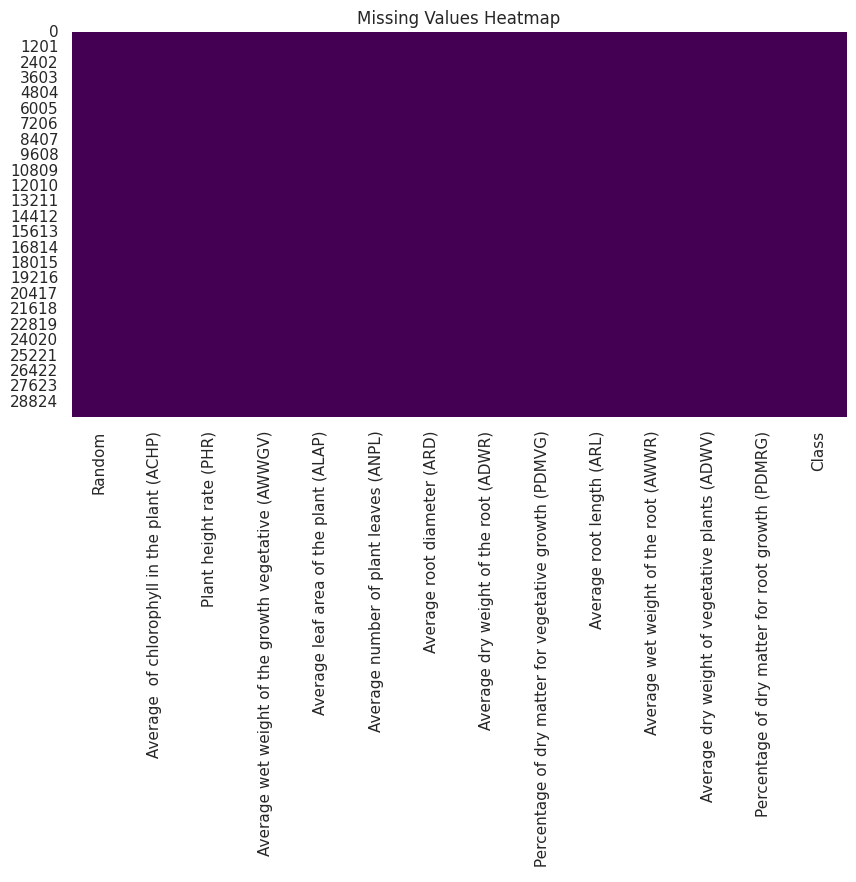

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cmap="viridis", cbar=False)

plt.title("Missing Values Heatmap")
plt.show()

The heatmap visually highlights missing values in the dataset. Missing values can negatively impact machine learning models and must be handled during preprocessing.

In [ ]:
df.duplicated().sum()

np.int64(0)

Duplicate rows may lead to biased results in machine learning models, so they should be removed during preprocessing.

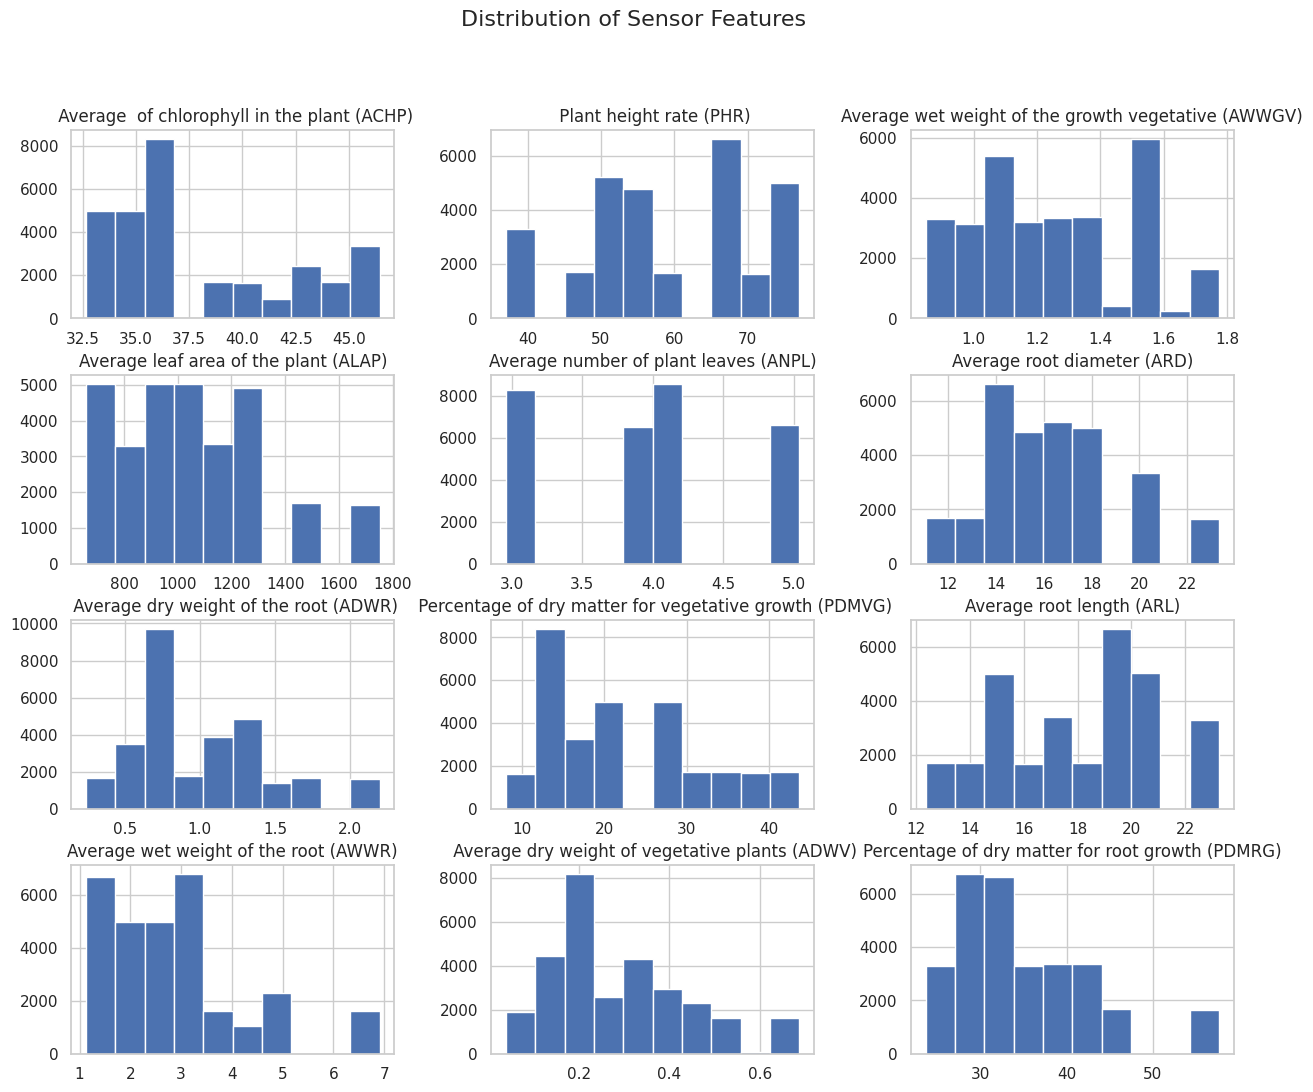

In [ ]:
df.hist(figsize=(15,12))
plt.suptitle("Distribution of Sensor Features", fontsize=16)
plt.show()

Histograms help analyze the distribution of environmental features collected by IoT sensors.

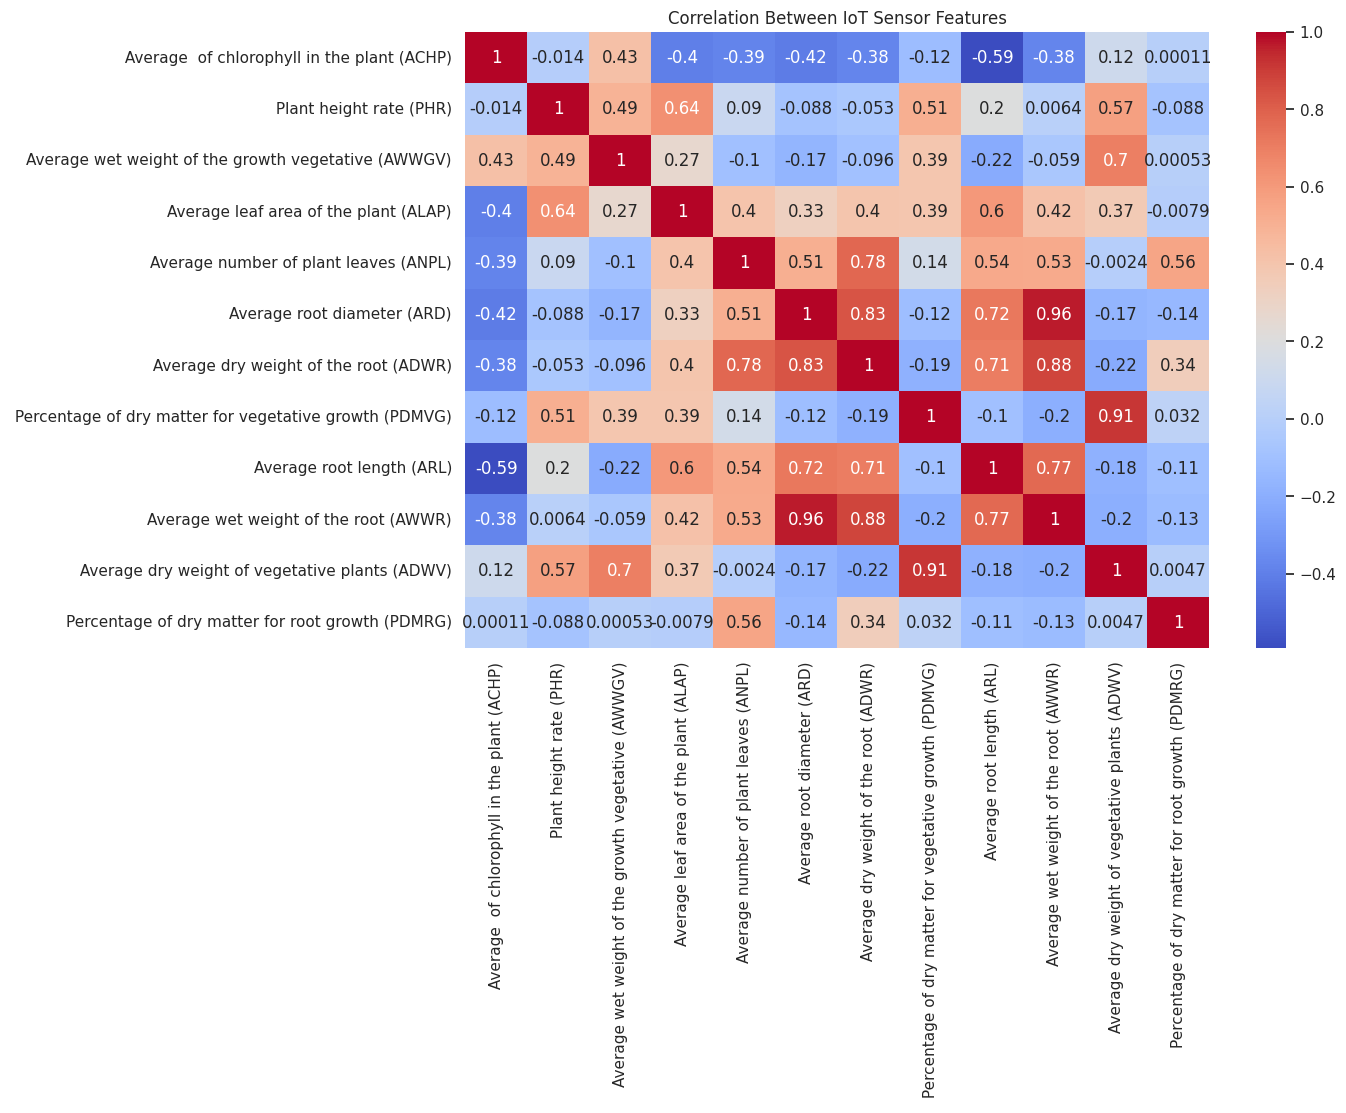

In [ ]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Between IoT Sensor Features")

plt.show()

Correlation analysis helps identify relationships between environmental variables that influence plant growth.

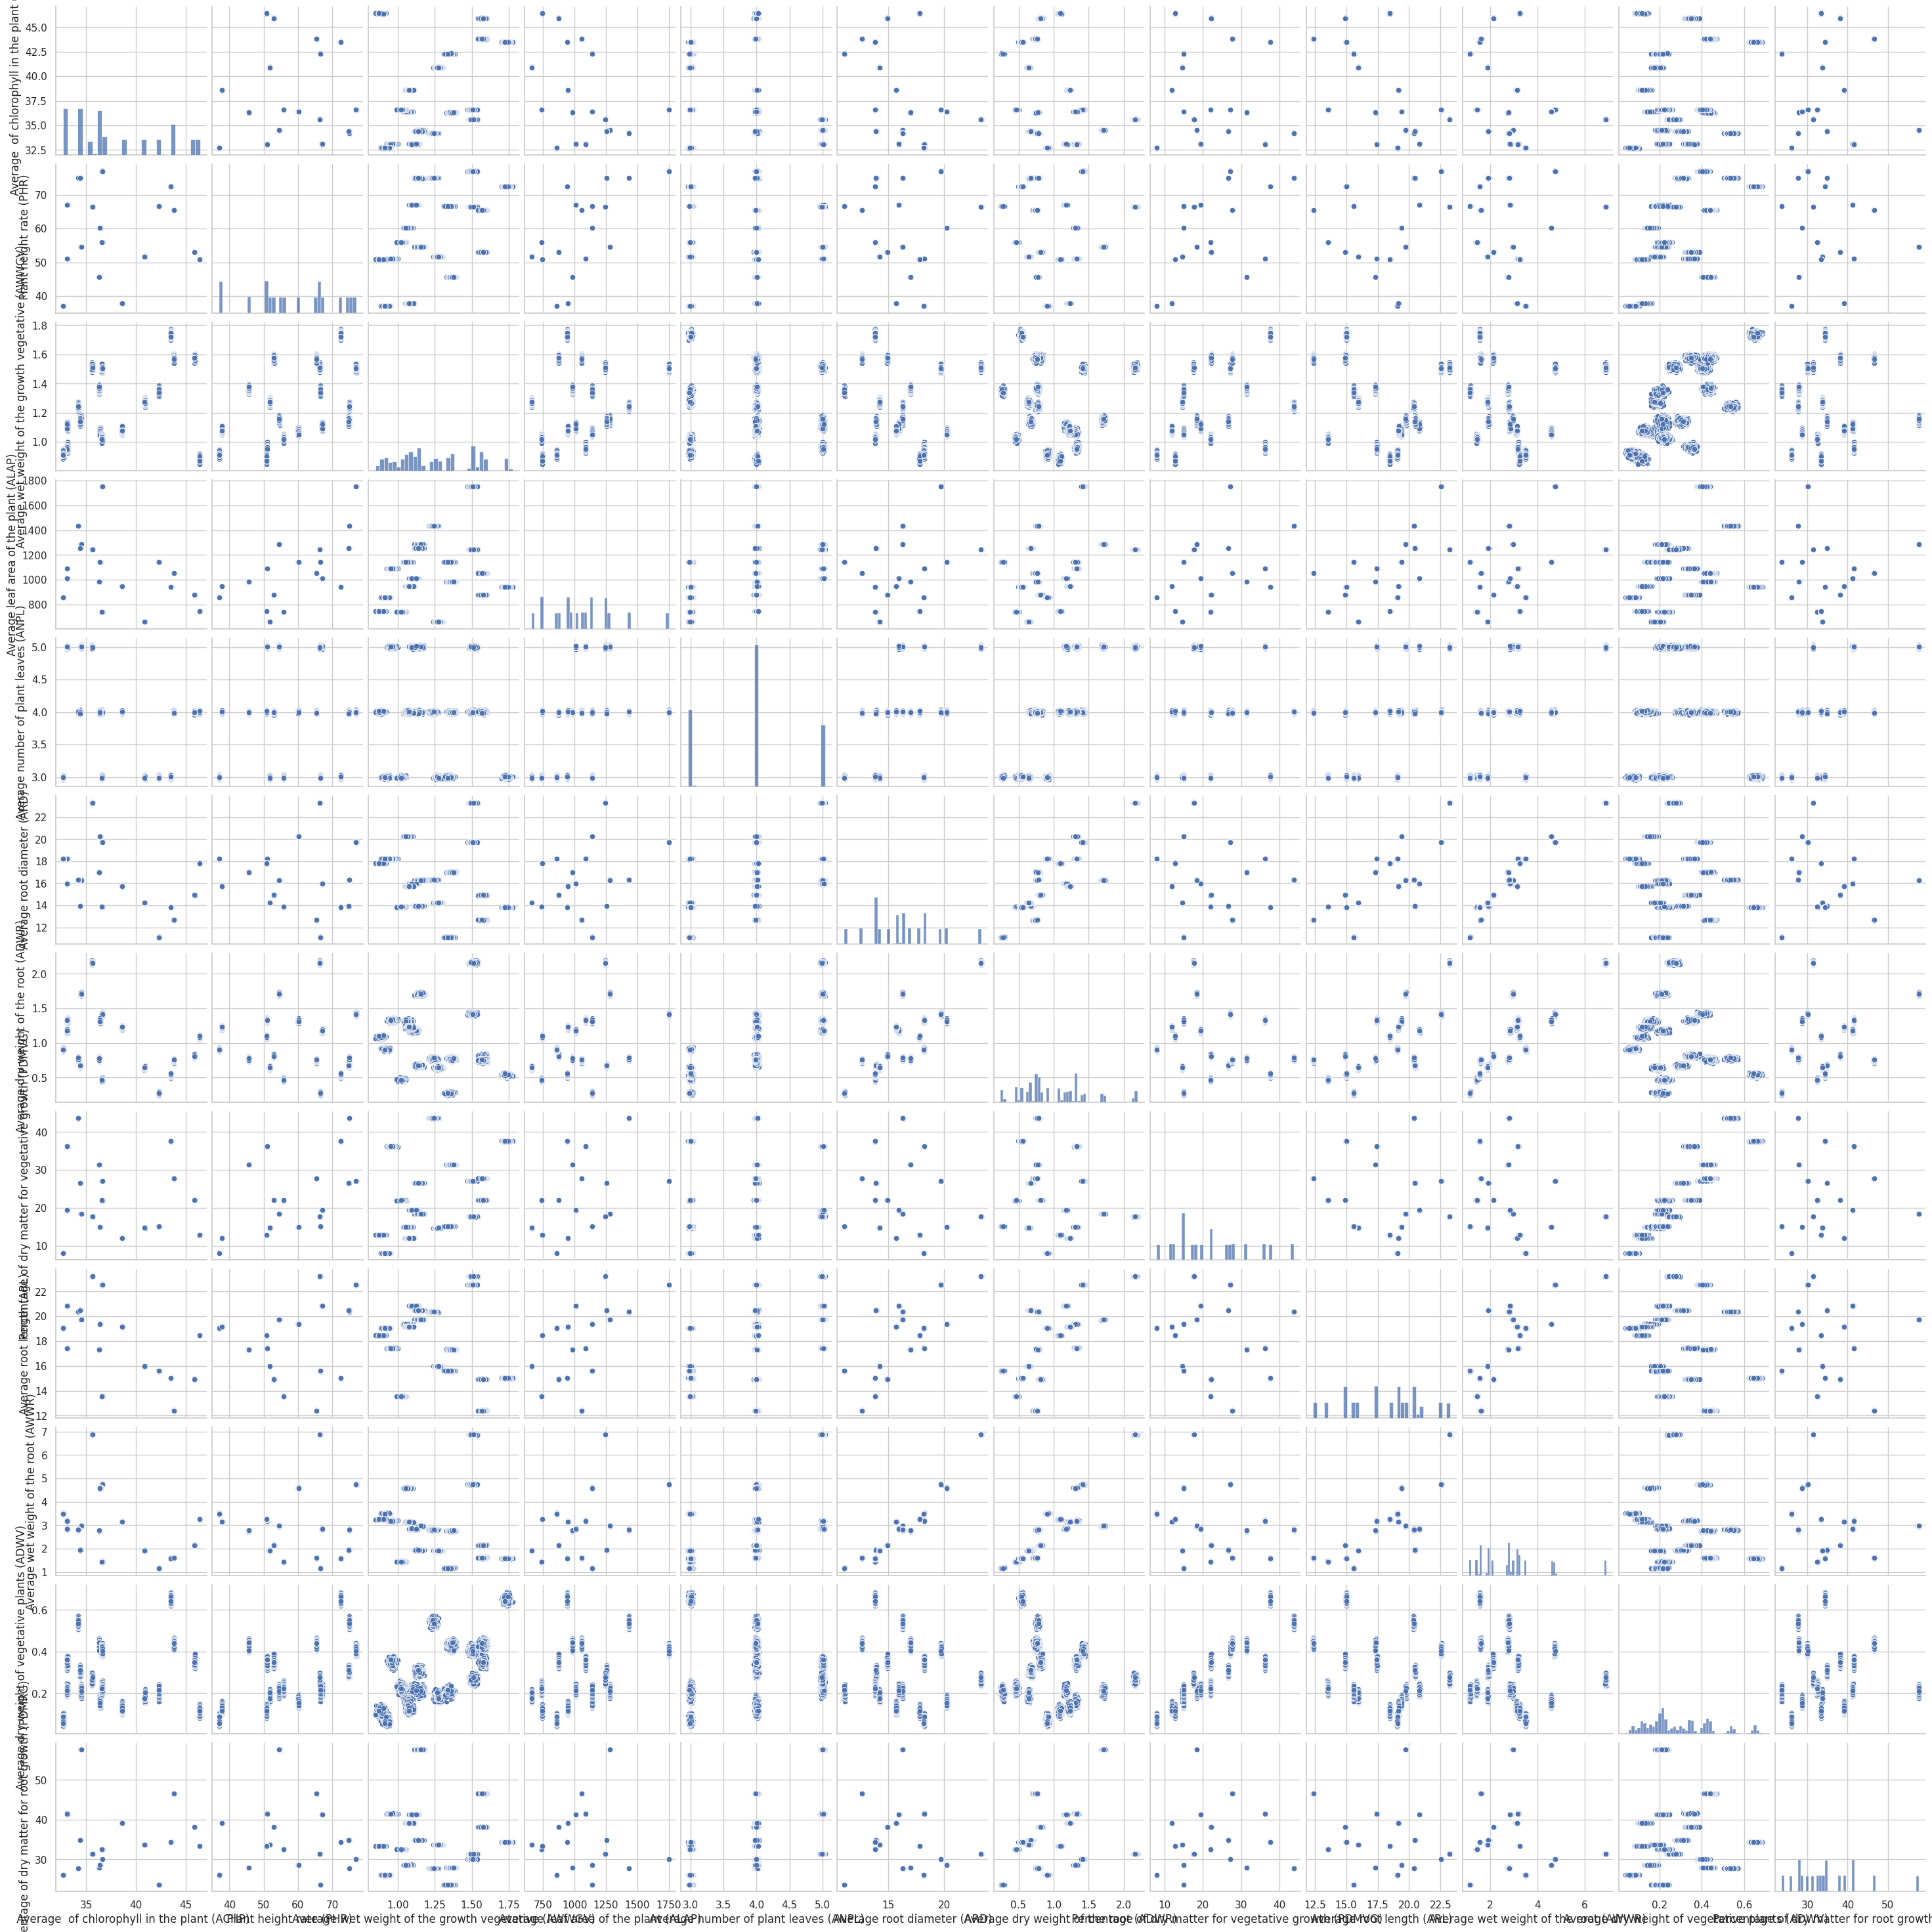

In [ ]:
sns.pairplot(df)

plt.show()

Pairplots help visualize relationships between multiple features simultaneously and detect patterns in the dataset.

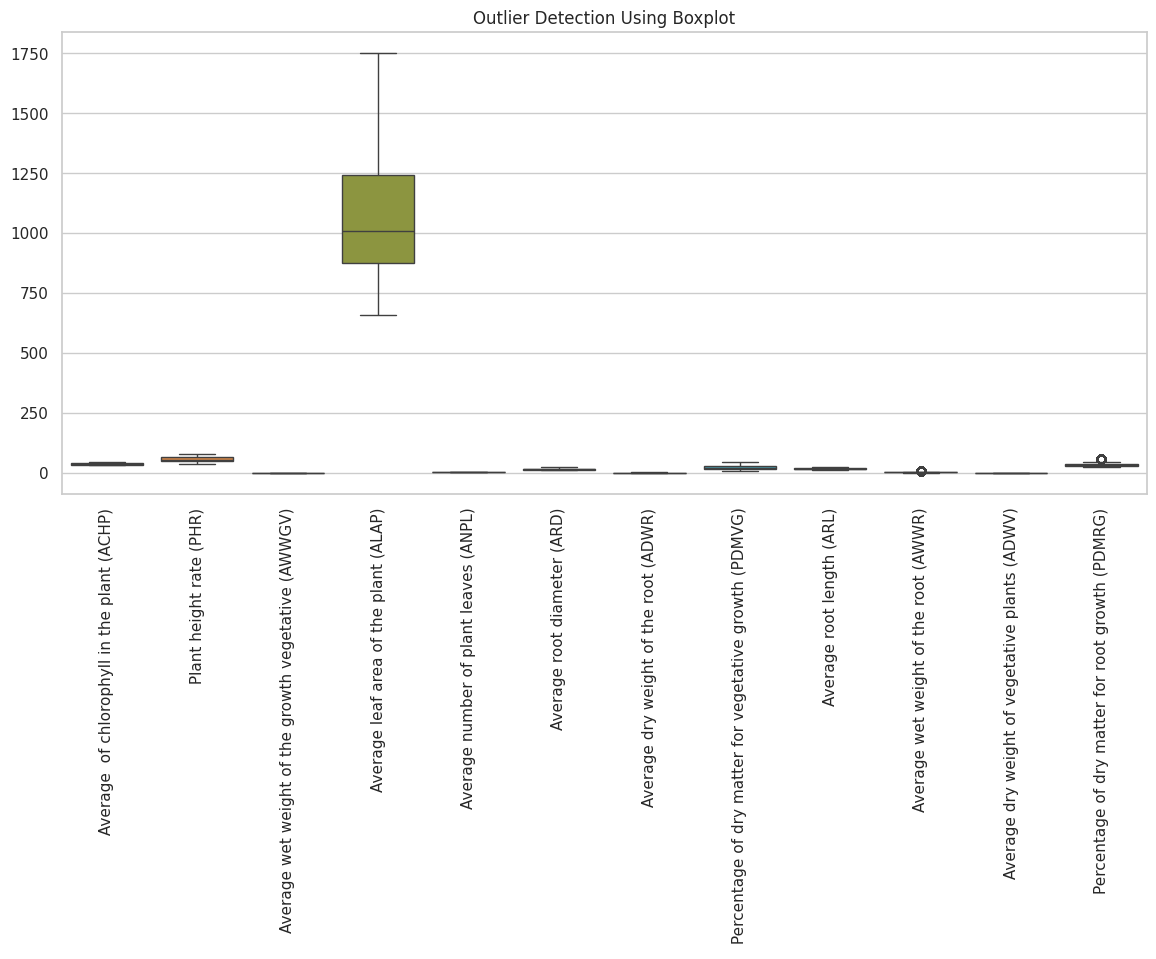

In [ ]:
plt.figure(figsize=(14,6))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.title("Outlier Detection Using Boxplot")

plt.show()

Boxplots help identify extreme values that may represent sensor errors or unusual environmental conditions.

In [ ]:
print(df.columns)

Index(['Random', ' Average  of chlorophyll in the plant (ACHP)',
       ' Plant height rate (PHR)',
       'Average wet weight of the growth vegetative (AWWGV)',
       'Average leaf area of the plant (ALAP)',
       'Average number of plant leaves (ANPL)', 'Average root diameter (ARD)',
       ' Average dry weight of the root (ADWR)',
       ' Percentage of dry matter for vegetative growth (PDMVG)',
       'Average root length (ARL)', 'Average wet weight of the root (AWWR)',
       ' Average dry weight of vegetative plants (ADWV)',
       'Percentage of dry matter for root growth (PDMRG)', 'Class'],
      dtype='object')


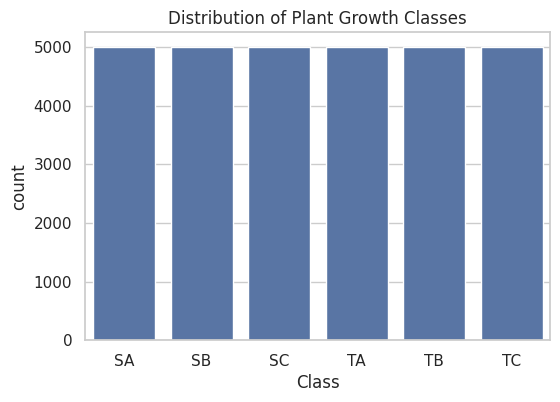

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x=df["Class"])

plt.title("Distribution of Plant Growth Classes")

plt.show()

This plot shows the number of samples for each plant growth category. Balanced classes improve machine learning performance.

In [ ]:
df = df.dropna()

Rows with missing values were removed to maintain data consistency and avoid errors during model training.

In [ ]:
df = df.drop_duplicates()

Duplicate records were removed to prevent bias and ensure that each observation is unique.

In [ ]:
encoder = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = encoder.fit_transform(df[col])

Categorical features were encoded into numerical values because machine learning algorithms require numerical input.

In [ ]:
scaler = StandardScaler()

num_cols = df.select_dtypes(include=np.number).columns

df[num_cols] = scaler.fit_transform(df[num_cols])

Feature scaling was applied to normalize the sensor data and ensure that all variables contribute equally to the model.

In [ ]:
df.head()

,Random,Average of chlorophyll in the plant (ACHP),Plant height rate (PHR),Average wet weight of the growth vegetative (AWWGV),Average leaf area of the plant (ALAP),Average number of plant leaves (ANPL),Average root diameter (ARD),Average dry weight of the root (ADWR),Percentage of dry matter for vegetative growth (PDMVG),Average root length (ARL),Average wet weight of the root (AWWR),Average dry weight of vegetative plants (ADWV),Percentage of dry matter for root growth (PDMRG),Class
0,-1.221496,-0.794106,-0.371576,-0.405751,0.846116,1.501617,-0.003772,1.546906,-0.446620,0.568736,0.031008,-0.546774,2.839675,-1.46385
1,-1.221496,-0.804111,-0.371517,-0.397292,0.846186,1.536557,-0.005668,1.534019,-0.446797,0.575486,0.026527,-0.501214,2.839649,-1.46385
2,0.001998,-1.116751,0.671423,-0.579753,-0.208780,1.512918,-0.105813,0.404157,-0.342262,0.944415,-0.033318,-0.607085,0.796160,-1.46385
3,-1.221496,-0.802020,-0.372238,-0.445144,0.846109,1.489928,-0.003151,1.567915,-0.445196,0.567733,0.029204,-0.455424,2.841145,-1.46385
4,1.225492,-0.397056,-1.120686,0.471363,-0.315178,0.083831,0.240778,-0.489942,0.914145,-0.252036,-0.103361,0.871722,-0.878165,-1.46385


After preprocessing, the dataset is clean and ready for machine learning model training.

In [ ]:
df.to_csv("preprocessed_iot_agriculture_dataset.csv", index=False)

The cleaned and preprocessed dataset was saved as a CSV file.
This file will be used in the next phase of the project to train machine learning models without repeating the preprocessing steps.

## Conclusion

The exploratory data analysis revealed important patterns in IoT greenhouse sensor data.
Environmental variables such as temperature, humidity, and soil moisture show relationships that may influence plant growth conditions.

After cleaning and preprocessing the dataset, it is now ready for the next phase where machine learning models will be trained to predict plant growth classes.